# **Exploratory Data Analysis of DICOM Image Metadata**

Analysis of the DICOM headers of every instance under `data/raw/images`
(Lung-PET-CT-Dx dataset). One row per `.dcm` instance is extracted with
`src.data.dicom_metadata.build_metadata_dataframe`, which reads the header
of each file (pixel data skipped) and caches the result to
`data/processed/image_metadata.parquet`.

The goal is to characterise the acquisition parameters of the dataset:
modalities present, image geometry, pixel representation, scanner vendors
and the modality-specific parameters of CT and PET.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data.dicom_metadata import build_metadata_dataframe

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

# Where the figures of this notebook are stored.
FIG_DIR = Path('../../results/reports/EDA/image_metadata')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches='tight')

/home/fmirfer/projects/PET-CT-Tumor-Segmentation-TFM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load metadata

The first run scans the ~250k DICOM headers (a few minutes) and writes the
parquet cache; later runs load the cache instantly.

In [2]:
df = build_metadata_dataframe(
    root='../../data/raw/images',
    cache_path='../../data/processed/image_metadata.parquet',
)
print(df.shape)
df.head()

(251135, 70)


,file_path,patient_folder,read_error,patient_id,patient_sex,patient_age,patient_size,patient_weight,patient_position,modality,manufacturer,model_name,software_versions,study_date,series_date,study_description,series_description,protocol_name,body_part,study_uid,series_uid,sop_uid,frame_of_reference_uid,image_type,rows,columns,slice_thickness,spacing_between_slices,slice_location,photometric,samples_per_pixel,bits_allocated,bits_stored,pixel_representation,rescale_slope,rescale_intercept,rescale_type,window_center,window_width,instance_number,series_number,acquisition_number,kvp,xray_tube_current,exposure,exposure_time,generator_power,filter_type,focal_spots,convolution_kernel,scan_options,spiral_pitch_factor,single_collimation_width,total_collimation_width,gantry_tilt,reconstruction_diameter,data_collection_diameter,table_height,pet_units,decay_correction,corrected_image,frame_duration,acquisition_time,pixel_spacing_row,pixel_spacing_col,image_position_z,radiopharmaceutical,radionuclide_total_dose,radionuclide_half_life,radiopharmaceutical_start_time
0,data/raw/images/Lung_Dx-A0182/25904/88200/65a9...,Lung_Dx-A0182,None,Lung_Dx-A0182,M,064Y,NaN,80.0,HFS,CT,SIEMENS,Biograph 64,VG51C,20090712,20090712,PET^08_Wholebody_Only (Adult),Range-CT WB 1.0 B30f-Tra-<ALPHA Range>,08_Wholebody_Only,ABDOMEN,1.3.6.1.4.1.14519.5.2.1.6655.2359.156741990384...,1.3.6.1.4.1.14519.5.2.1.6655.2359.199660713750...,1.3.6.1.4.1.14519.5.2.1.6655.2359.850972951927...,NaN,DERIVED\SECONDARY\OTHER\CSA FUSED MPR\\CSAPARA...,512,512,NaN,NaN,NaN,RGB,3,8,8,0,NaN,NaN,NaN,NaN,NaN,284,7,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123444.028000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,data/raw/images/Lung_Dx-A0182/25904/88200/c285...,Lung_Dx-A0182,None,Lung_Dx-A0182,M,064Y,NaN,80.0,HFS,CT,SIEMENS,Biograph 64,VG51C,20090712,20090712,PET^08_Wholebody_Only (Adult),Range-CT WB 1.0 B30f-Tra-<ALPHA Range>,08_Wholebody_Only,ABDOMEN,1.3.6.1.4.1.14519.5.2.1.6655.2359.156741990384...,1.3.6.1.4.1.14519.5.2.1.6655.2359.199660713750...,1.3.6.1.4.1.14519.5.2.1.6655.2359.703461027754...,NaN,DERIVED\SECONDARY\OTHER\CSA FUSED MPR\\CSAPARA...,512,512,NaN,NaN,NaN,RGB,3,8,8,0,NaN,NaN,NaN,NaN,NaN,203,7,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123444.028000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,data/raw/images/Lung_Dx-A0182/25904/88200/14ad...,Lung_Dx-A0182,None,Lung_Dx-A0182,M,064Y,NaN,80.0,HFS,CT,SIEMENS,Biograph 64,VG51C,20090712,20090712,PET^08_Wholebody_Only (Adult),Range-CT WB 1.0 B30f-Tra-<ALPHA Range>,08_Wholebody_Only,ABDOMEN,1.3.6.1.4.1.14519.5.2.1.6655.2359.156741990384...,1.3.6.1.4.1.14519.5.2.1.6655.2359.199660713750...,1.3.6.1.4.1.14519.5.2.1.6655.2359.228510567880...,NaN,DERIVED\SECONDARY\OTHER\CSA FUSED MPR\\CSAPARA...,512,512,NaN,NaN,NaN,RGB,3,8,8,0,NaN,NaN,NaN,NaN,NaN,142,7,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123444.028000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,data/raw/images/Lung_Dx-A0182/25904/88200/4b3f...,Lung_Dx-A0182,None,Lung_Dx-A0182,M,064Y,NaN,80.0,HFS,CT,SIEMENS,Biograph 64,VG51C,20090712,20090712,PET^08_Wholebody_Only (Adult),Range-CT WB 1.0 B30f-Tra-<ALPHA Range>,08_Wholebody_Only,ABDOMEN,1.3.6.1.4.1.14519.5.2.1.6655.2359.156741990384...,1.3.6.1.4.1.14519.5.2.1.6655.2359.199660713750...,1.3.6.1.4.1.14519.5.2.1.6655.2359.303048771327...,NaN,DERIVED\SECONDARY\OTHER\CSA FUSED MPR\\CSAPARA...,512,512,NaN,NaN,NaN,RGB,3,8,8,0,NaN,NaN,NaN,NaN,NaN,139,7,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123444.028000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,data/raw/images/Lung_Dx-A0182/25904/88200/bdb9...,Lung_Dx-A0182,None,Lung_Dx-A0182,M,064Y,NaN,80.0,HFS,CT,SIEMENS,Biograph 64,VG51C,20090712,20090712,PET^08_Wholebody_Only (Adult),Range-CT WB 1.0 B30f-Tra-<ALPHA Range>,08_Wholebody_Only,ABDOMEN,1.3.6.1.4.1.14519.5.2.1.6655.2359.156741990384...,1.3.6.1.4.1.14519.5.2.1.6655.2359.199660713750...,1.3.6.1.4.1.14519.5.2.1.6655.2359.460357811207

In [3]:
# Any unreadable / corrupt files?
n_err = df['read_error'].notna().sum()
print(f'Instances with read errors: {n_err}')
if n_err:
    display(df.loc[df['read_error'].notna(), ['file_path', 'read_error']].head())

Instances with read errors: 0


## 1. Dataset overview

Counts of patients, studies, series and instances, and the split by modality.

In [4]:
overview = {
    'instances (.dcm)': len(df),
    'patients': df['patient_folder'].nunique(),
    'studies': df['study_uid'].nunique(),
    'series': df['series_uid'].nunique(),
}
pd.Series(overview, name='count').to_frame()

,count
instances (.dcm),251135
patients,355
studies,436
series,1295


In [5]:
# Instances per modality.
mod_counts = df['modality'].value_counts(dropna=False)
display(mod_counts.to_frame('instances'))

# Series per modality (a series is the natural acquisition unit).
series_mod = df.groupby('series_uid')['modality'].first().value_counts(dropna=False)
display(series_mod.to_frame('series'))

,instances
modality,
CT,205459
PT,45676


,series
modality,
CT,1162
PT,133


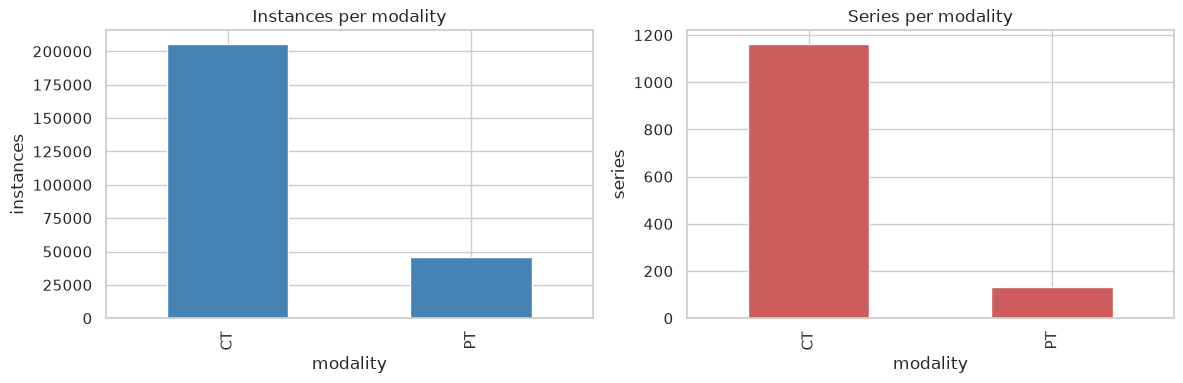

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mod_counts.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Instances per modality'); axes[0].set_ylabel('instances')
series_mod.plot.bar(ax=axes[1], color='indianred')
axes[1].set_title('Series per modality'); axes[1].set_ylabel('series')
savefig('modality_counts.png')
plt.show()

### Cohort sub-groups
Patients are coded `Lung_Dx-<A|B|E|G>NNNN`. The letter encodes the
diagnostic sub-cohort.

In [7]:
cohort = df.drop_duplicates('patient_folder')['patient_folder'].str.extract(r'Lung_Dx-([A-Z])')[0]
cohort.value_counts().sort_index().to_frame('patients')

,patients
0,
A,251
B,38
E,5
G,61


## 2. Series composition
Number of slices per series and per-patient modality availability.

In [8]:
slices_per_series = df.groupby(['series_uid']).agg(
    modality=('modality', 'first'),
    n_slices=('sop_uid', 'size'),
).reset_index()
slices_per_series.groupby('modality')['n_slices'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
modality,,,,,,,,
CT,1162.0,176.8,135.3,1.0,54.0,168.0,270.0,852.0
PT,133.0,343.4,78.6,136.0,273.0,357.0,419.0,481.0


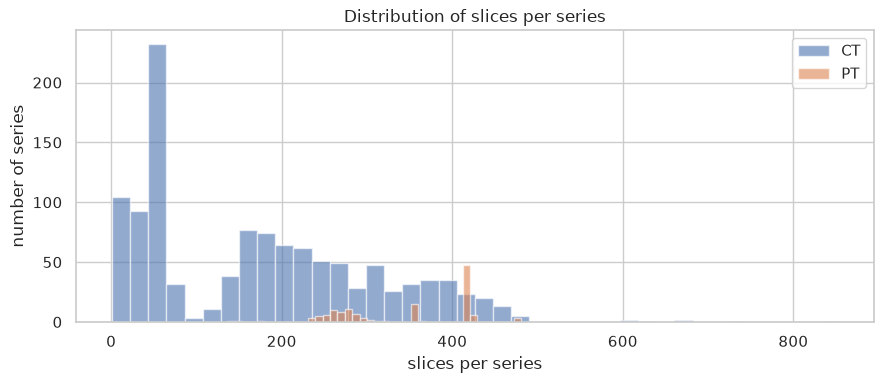

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
for mod, sub in slices_per_series.groupby('modality'):
    ax.hist(sub['n_slices'], bins=40, alpha=0.6, label=mod)
ax.set_xlabel('slices per series'); ax.set_ylabel('number of series')
ax.set_title('Distribution of slices per series'); ax.legend()
savefig('slices_per_series.png')
plt.show()

In [10]:
# Which modalities does each patient have?
pat_mod = df.groupby('patient_folder')['modality'].agg(lambda s: '+'.join(sorted(set(s.dropna()))))
pat_mod.value_counts().to_frame('patients')

,patients
modality,
CT,222
CT+PT,133


## 3. Metadata completeness
Fraction of present (non-null) values for every extracted tag. Modality-
specific tags (CT vs PET) are expected to be empty for the other modality.

In [11]:
completeness = df.notna().mean().sort_values()
completeness_pct = (completeness * 100).round(1)
completeness_pct.to_frame('present_%')

,present_%
read_error,0.0
patient_size,2.8
spacing_between_slices,16.6
radiopharmaceutical_start_time,18.2
pet_units,18.2
...,...
instance_number,100.0
samples_per_pixel,100.0
bits_allocated,100.0
study_description,100.0


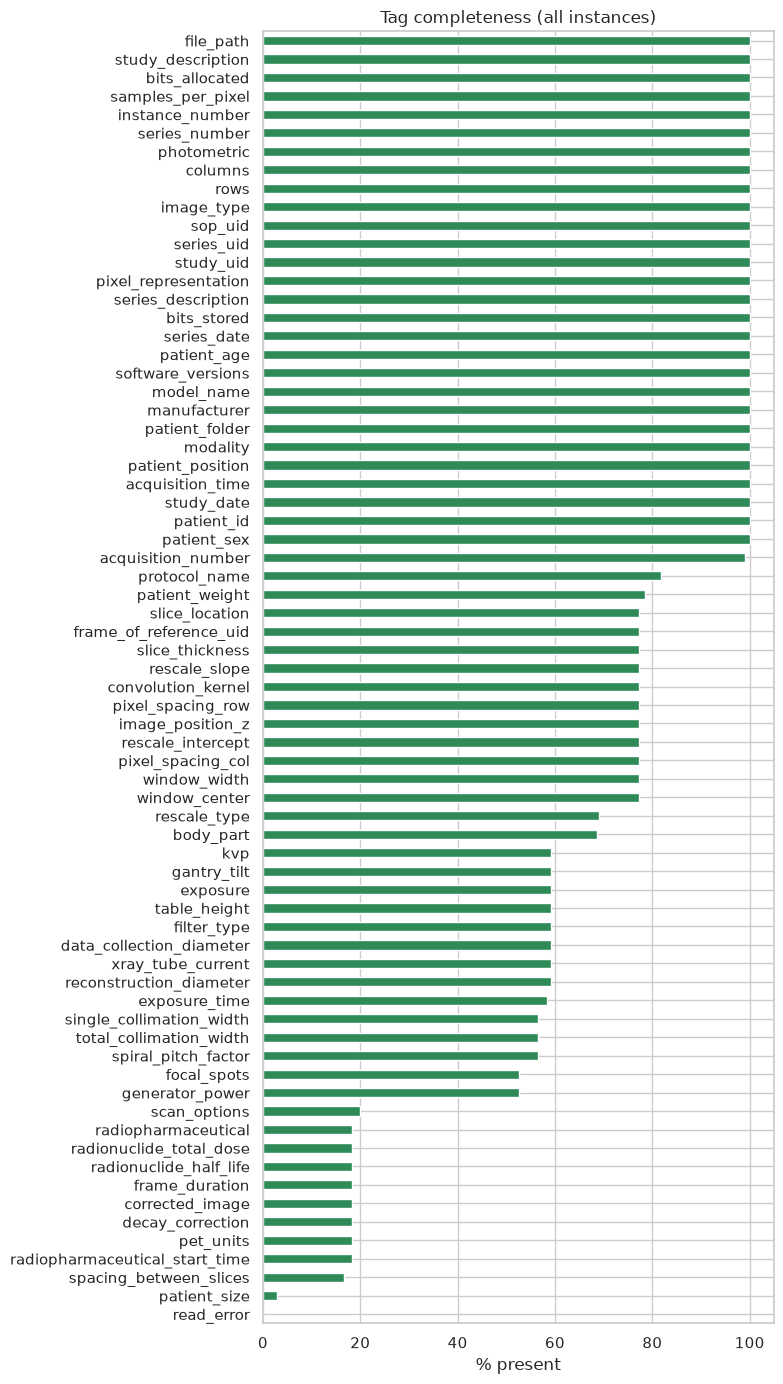

In [12]:
fig, ax = plt.subplots(figsize=(8, 14))
completeness_pct.plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('% present'); ax.set_title('Tag completeness (all instances)')
savefig('completeness.png')
plt.show()

In [13]:
# Completeness split by modality makes the CT/PET-specific tags obvious.
comp_by_mod = df.groupby('modality').apply(
    lambda g: g.notna().mean(), include_groups=False
).T
(comp_by_mod * 100).round(1)

modality,CT,PT
file_path,100.0,100.0
patient_folder,100.0,100.0
read_error,0.0,0.0
patient_id,100.0,100.0
patient_sex,100.0,100.0
...,...,...
image_position_z,72.3,100.0
radiopharmaceutical,0.0,100.0
radionuclide_total_dose,0.0,100.0
radionuclide_half_life,0.0,100.0


## 4. Image geometry
Matrix size (Rows x Columns), in-plane pixel spacing and slice thickness,
analysed per modality.

In [14]:
# Matrix size.
df['matrix'] = df['rows'].astype('Int64').astype(str) + 'x' + df['columns'].astype('Int64').astype(str)
df.groupby('modality')['matrix'].value_counts().to_frame('instances')

instances
modality matrix            
CT       512x512     205451
         484x484          7
         752x888          1
PT       200x200      45676

In [15]:
geom = ['pixel_spacing_row', 'pixel_spacing_col', 'slice_thickness', 'spacing_between_slices']
df.groupby('modality')[geom].describe().T.round(3)

modality                              CT         PT
pixel_spacing_row      count  148457.000  45676.000
                       mean        0.767      4.073
                       std         0.061      0.000
                       min         0.545      4.073
                       25%         0.732      4.073
                       50%         0.781      4.073
                       75%         0.781      4.073
                       max         0.977      4.073
pixel_spacing_col      count  148457.000  45676.000
                       mean        0.767      4.073
                       std         0.061      0.000
                       min         0.545      4.073
                       25%         0.732      4.073
                       50%         0.781      4.073
                       75%         0.781      4.073
                       max         0.977      4.073
slice_thickness        count  148457.000  45676.000
                       mean        2.023      2.423
                       std         2.143      0.478
                       min         0.625      2.027
                       25%         1.000      2.027
                       50%         1.000      2.027
                       75%         1.250      3.000
                       max       410.545      3.000
spacing_between_slices count   41764.000      0.000
                       mean        3.573        NaN
                       std         1.927        NaN
                       min         0.000        NaN
                       25%         1.000        NaN
                       50%         5.000        NaN
                       75%         5.000        NaN
                       max        10.000        NaN

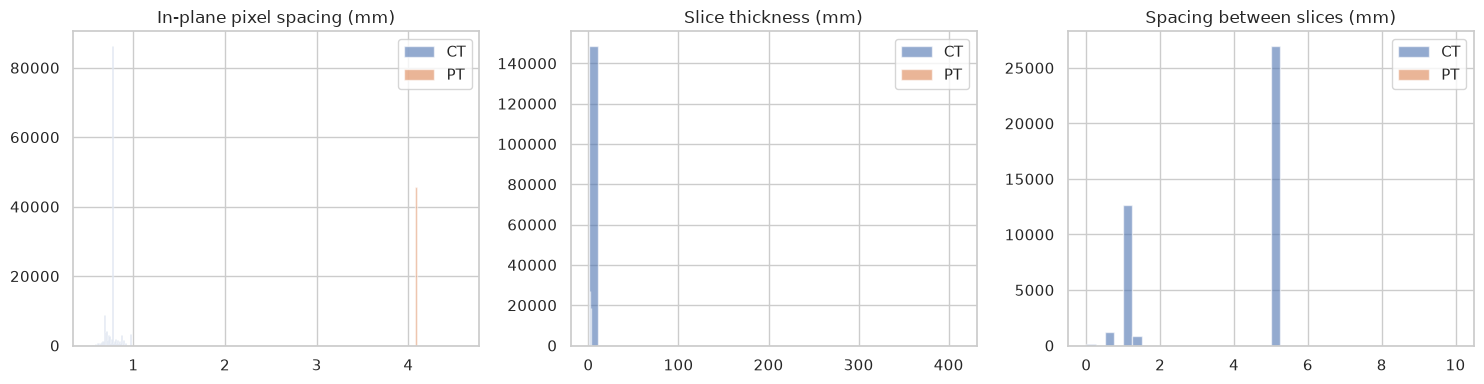

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ['pixel_spacing_row', 'slice_thickness', 'spacing_between_slices'],
    ['In-plane pixel spacing (mm)', 'Slice thickness (mm)', 'Spacing between slices (mm)']):
    for mod, sub in df.groupby('modality'):
        ax.hist(sub[col].dropna(), bins=40, alpha=0.6, label=mod)
    ax.set_title(title); ax.legend()
savefig('geometry.png')
plt.show()

## 5. Pixel representation & intensity rescaling
Bit depth, photometric interpretation and the rescale slope/intercept used
to map stored values to HU (CT) or activity (PET).

In [17]:
for col in ['photometric', 'bits_allocated', 'bits_stored', 'pixel_representation', 'rescale_type']:
    print(f'--- {col} ---')
    print(df.groupby('modality')[col].value_counts(dropna=False))
    print()

--- photometric ---
modality  photometric
CT        MONOCHROME2    148457
          RGB             57002
PT        MONOCHROME2     45676
Name: count, dtype: int64

--- bits_allocated ---
modality  bits_allocated
CT        16                148457
          8                  57002
PT        16                 45676
Name: count, dtype: int64

--- bits_stored ---
modality  bits_stored
CT        12             115049
          8               57002
          16              33408
PT        16              45676
Name: count, dtype: int64

--- pixel_representation ---
modality  pixel_representation
CT        0                       172051
          1                        33408
PT        0                        45676
Name: count, dtype: int64

--- rescale_type ---
modality  rescale_type
CT        HU              127898
          NaN              77561
PT        BQML             45676
Name: count, dtype: int64



In [18]:
df.groupby('modality')[['rescale_slope', 'rescale_intercept']].describe().T.round(3)

modality                       CT         PT
rescale_slope     count  148457.0  45676.000
                  mean        1.0      2.239
                  std         0.0      3.028
                  min         1.0      0.042
                  25%         1.0      0.215
                  50%         1.0      1.523
                  75%         1.0      2.665
                  max         1.0     19.463
rescale_intercept count  148457.0  45676.000
                  mean    -1024.0      0.000
                  std         0.0      0.000
                  min     -1024.0      0.000
                  25%     -1024.0      0.000
                  50%     -1024.0      0.000
                  75%     -1024.0      0.000
                  max     -1024.0      0.000

## 6. Scanner vendors and models

In [19]:
display(df.groupby('modality')['manufacturer'].value_counts(dropna=False).to_frame('instances'))
display(df.groupby('modality')['model_name'].value_counts(dropna=False).head(20).to_frame('instances'))

instances
modality manufacturer                 
CT       SIEMENS                155584
         GE MEDICAL SYSTEMS      33408
         Philips                 16467
PT       SIEMENS                 45676

instances
modality model_name                   
CT       Biograph 64            124497
         Biograph64              26995
         Discovery CT750 HD      22547
         iCT 256                 14310
         LightSpeed VCT           7438
         Sensation 10             4092
         Brilliance16             2157
         Revolution CT            1715
         Optima CT660             1035
         LightSpeed Pro 16         673
PT       Biograph 64_mCT         39738
         Biograph64_mCT           5938

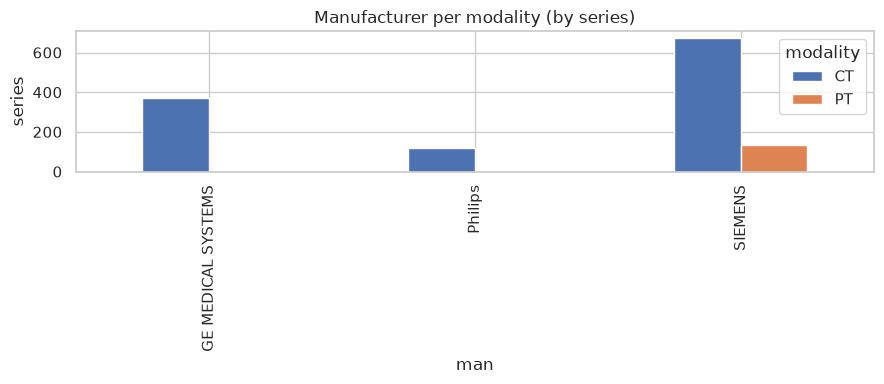

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
(df.groupby('series_uid').agg(modality=('modality','first'), man=('manufacturer','first'))
   .groupby(['modality','man']).size().unstack(fill_value=0).T
   .plot.bar(ax=ax))
ax.set_ylabel('series'); ax.set_title('Manufacturer per modality (by series)')
savefig('manufacturers.png')
plt.show()

## 7. CT acquisition parameters
Tube voltage/current, exposure, reconstruction kernel and other CT-specific
settings.

In [21]:
ct = df[df['modality'] == 'CT']
ct_num = ['kvp', 'xray_tube_current', 'exposure', 'exposure_time', 'generator_power',
          'spiral_pitch_factor', 'reconstruction_diameter', 'gantry_tilt']
ct[ct_num].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
kvp,148457.0,117.63,8.17,80.0,120.0,120.0,120.0,140.00
xray_tube_current,148457.0,242.70,111.07,40.0,168.0,217.0,286.0,660.00
exposure,148457.0,100.37,71.74,0.0,47.0,96.0,139.0,387.00
exposure_time,146300.0,523.82,52.86,300.0,500.0,500.0,503.0,4176.00
generator_power,131990.0,9483.88,17793.78,13.0,28.0,35.0,2500.0,78000.00
spiral_pitch_factor,142108.0,1.06,0.14,0.8,1.0,1.0,1.0,1.38
reconstruction_diameter,148456.0,392.58,31.12,279.0,375.0,400.0,400.0,500.00
gantry_tilt,148457.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00


In [22]:
for col in ['kvp', 'convolution_kernel', 'filter_type', 'scan_options']:
    print(f'--- {col} ---')
    print(ct[col].value_counts(dropna=False).head(10))
    print()

--- kvp ---
kvp
120.0    132358
NaN       57002
100.0     11466
80.0       3582
140.0      1051
Name: count, dtype: int64

--- convolution_kernel ---
convolution_kernel
NaN               57002
B70f              50813
B31f              33813
STANDARD          22692
B30f              12205
LUNG              10610
YB                 7735
B                  5989
IMR1,SharpPlus     1699
B40f               1535
Name: count, dtype: int64

--- filter_type ---
filter_type
FLAT           94490
NaN            57002
BODY FILTER    33408
YB              7735
B               5989
0               4092
IMR             1699
L               1044
Name: count, dtype: int64

--- scan_options ---
scan_options
NaN             155584
HELICAL MODE     33308
HELIX            16467
AXIAL MODE          99
SCOUT MODE           1
Name: count, dtype: int64



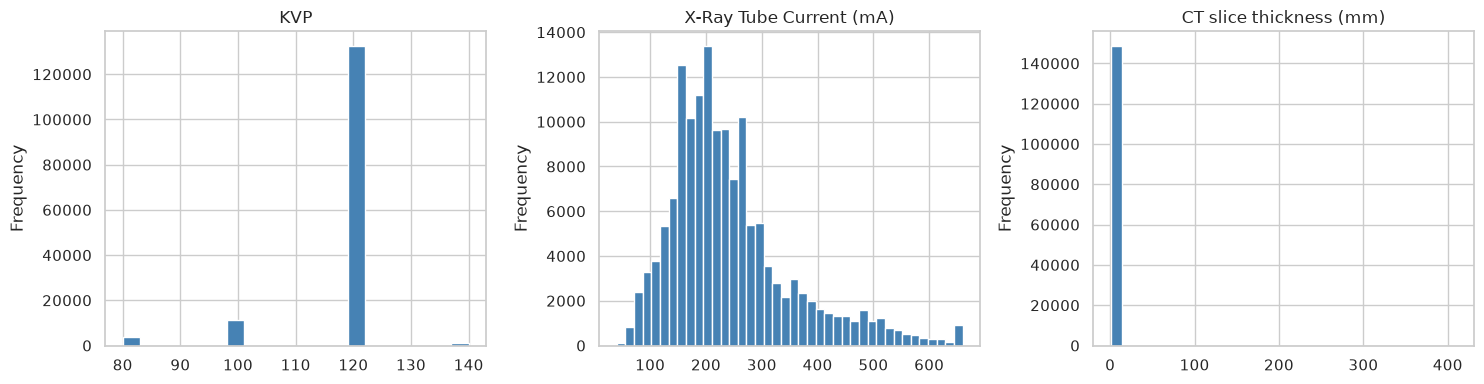

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ct['kvp'].dropna().plot.hist(ax=axes[0], bins=20, color='steelblue'); axes[0].set_title('KVP')
ct['xray_tube_current'].dropna().plot.hist(ax=axes[1], bins=40, color='steelblue'); axes[1].set_title('X-Ray Tube Current (mA)')
ct['slice_thickness'].dropna().plot.hist(ax=axes[2], bins=30, color='steelblue'); axes[2].set_title('CT slice thickness (mm)')
savefig('ct_parameters.png')
plt.show()

## 8. PET quantification parameters
Units, decay correction, radiopharmaceutical and injected dose. These drive
any SUV computation downstream.

In [24]:
pet = df[df['modality'] == 'PT']
for col in ['pet_units', 'decay_correction', 'corrected_image', 'radiopharmaceutical']:
    print(f'--- {col} ---')
    print(pet[col].value_counts(dropna=False).head(10))
    print()

--- pet_units ---
pet_units
BQML    45676
Name: count, dtype: int64

--- decay_correction ---
decay_correction
START    45676
Name: count, dtype: int64

--- corrected_image ---
corrected_image
NORM\DTIM\ATTN\SCAT\DECY\RAN    45676
Name: count, dtype: int64

--- radiopharmaceutical ---
radiopharmaceutical
Fluorodeoxyglucose    45676
Name: count, dtype: int64



In [25]:
pet_num = ['radionuclide_total_dose', 'radionuclide_half_life', 'frame_duration', 'patient_weight']
pet[pet_num].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
radionuclide_total_dose,45676.0,3.035547e+08,60525469.47,185000000.0,257890000.0,299700000.0,347800000.0,469900000.0
radionuclide_half_life,45676.0,6.586200e+03,0.00,6586.2,6586.2,6586.2,6586.2,6586.2
frame_duration,45676.0,1.186264e+05,28503.87,36263.0,90000.0,120000.0,137942.5,221013.0
patient_weight,45676.0,6.826000e+01,13.26,35.5,58.3,65.0,76.4,103.0


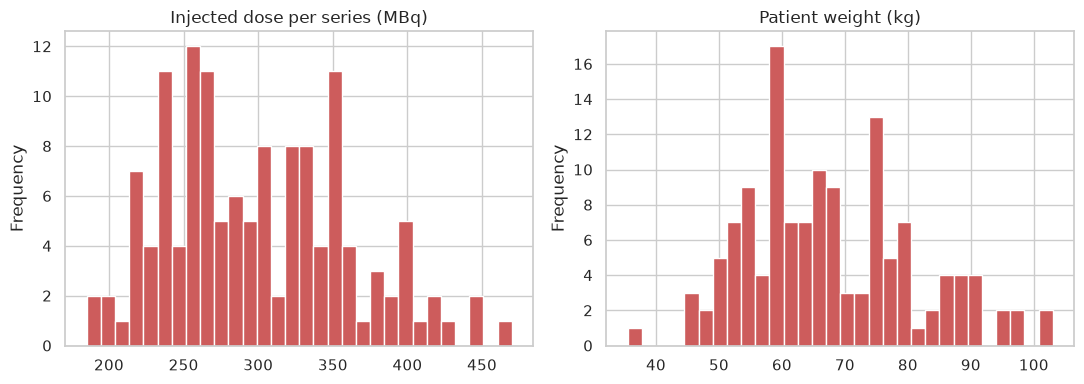

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
(pet.groupby('series_uid')['radionuclide_total_dose'].first().dropna() / 1e6).plot.hist(
    ax=axes[0], bins=30, color='indianred'); axes[0].set_title('Injected dose per series (MBq)')
pet.groupby('series_uid')['patient_weight'].first().dropna().plot.hist(
    ax=axes[1], bins=30, color='indianred'); axes[1].set_title('Patient weight (kg)')
savefig('pet_parameters.png')
plt.show()

## 9. Intra-series consistency
Geometry tags should be constant within a series. We flag series whose
pixel spacing, matrix size or slice thickness vary across slices.

In [27]:
def n_unique(s):
    return s.nunique(dropna=True)

consistency = df.groupby('series_uid').agg(
    modality=('modality', 'first'),
    rows=('rows', n_unique),
    cols=('columns', n_unique),
    px_spacing=('pixel_spacing_row', n_unique),
    slice_thickness=('slice_thickness', n_unique),
)
varying = consistency[(consistency[['rows', 'cols', 'px_spacing', 'slice_thickness']] > 1).any(axis=1)]
print(f'Series with intra-series geometry variation: {len(varying)} / {len(consistency)}')
varying.head(20)

Series with intra-series geometry variation: 7 / 1295


,modality,rows,cols,px_spacing,slice_thickness
series_uid,,,,,
1.3.6.1.4.1.14519.5.2.1.6655.2359.121512289381921764538031171441,CT,2,2,0,0
1.3.6.1.4.1.14519.5.2.1.6655.2359.186845325068247092494975679915,CT,2,2,0,0
1.3.6.1.4.1.14519.5.2.1.6655.2359.277170968794139123031308770245,CT,2,2,0,0
1.3.6.1.4.1.14519.5.2.1.6655.2359.277986224354213456851408268088,CT,2,2,0,0
1.3.6.1.4.1.14519.5.2.1.6655.2359.326811069800549626124045187711,CT,2,2,0,0
1.3.6.1.4.1.14519.5.2.1.6655.2359.382962623208327425359678678942,CT,2,2,0,0
1.3.6.1.4.1.14519.5.2.1.6655.2359.783468765668613851769605213642,CT,2,2,0,0


## 10. Summary of findings

**Cohort & structure** — 251,135 DICOM instances were read with **0 read errors**,
spanning **355 patients**, 436 studies and **1,295 series**. Patients split into
sub-cohorts A (251), B (38), E (5) and G (61). Every patient has CT; **133 patients
also have PET** (`CT+PT`), the remaining 222 are CT-only. Series count: 1,162 CT vs
133 PET; slices/series average ~177 for CT (1–852) and ~343 for PET (136–481).

**Two modalities, two regimes**
- **CT** — 205,459 instances, scanned by SIEMENS (673 series), GE (370) and Philips
  (119). Predominantly `120 kVp` (also 100/80/140), median tube current ~217 mA,
  pitch ~1.0, gantry tilt 0. Reconstruction kernels are vendor-specific
  (Siemens `B70f`/`B31f`/`B30f`, GE `STANDARD`/`LUNG`, Philips `IMR`).
- **PET** — 45,676 instances, all SIEMENS, all **FDG** (Fluorodeoxyglucose),
  units **BQML**, fully corrected (`NORM\\DTIM\\ATTN\\SCAT\\DECY\\RAN`),
  decay-corrected at START. Injected dose ~303 MBq (185–470), half-life 6586.2 s
  (F-18), patient weight 35.5–103 kg → **SUV-bw is computable** from the headers.

**⚠ Key data-quality finding — derived RGB images mixed into "CT"** — of the 205,459
CT instances, only **148,457 are primary grayscale CT** (MONOCHROME2, 16-bit stored
as 12/16-bit, rescale slope 1 / intercept −1024 → HU). The other **57,002 are
DERIVED/SECONDARY RGB "CSA FUSED MPR / Range" overview images** (8-bit, RGB, no
KVP/kernel/HU), grouped in **281 pure-RGB series** belonging exactly to the 133 PET
patients. **These must be excluded** before any HU-based preprocessing or
segmentation (filter `photometric == 'MONOCHROME2'`, leaving 881 primary CT series).

**Geometry**
- Primary CT: matrix **512×512** (a handful of 484×484 and one 752×888), in-plane
  spacing 0.55–0.98 mm (median 0.78), slice thickness mostly 1.0 mm — the 410 mm
  maximum is a degenerate localizer outlier. → **anisotropic, vendor/protocol-mixed**;
  resampling to a common spacing will be needed.
- PET: matrix **200×200**, isotropic in-plane spacing **4.073 mm** (constant),
  slice thickness 2.027–3.0 mm. PET and CT live on **different grids**, so
  registration / resampling to a shared frame is required before fusion.

**Consistency** — only **7 of 1,295 series** show intra-series geometry variation
(a localizer of a different matrix size mixed in); **99.5%** of series are internally
consistent.

**Implications for the segmentation pipeline**
1. Filter out the 57,002 RGB secondary-capture images (keep MONOCHROME2).
2. Apply `rescale_slope`/`rescale_intercept` to recover HU (CT) and BQML→SUV (PET).
3. Resample CT and PET to a common, isotropic spacing and register them
   (different matrices and pixel spacings).
4. Expect vendor/kernel heterogeneity in CT — consider it a normalization /
   harmonization factor.
